In [2]:

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np  
import sklearn

In [3]:
sales_df =pd.read_csv(r'C:\ironhack\labs\iron_kaggle\sales.csv')

In [4]:
sales_df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [5]:
sales_df.describe(
)

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [6]:
sales_df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [40]:
sales_df['state_holiday'] = sales_df['state_holiday'].astype(str)

sales_df_encoded = pd.get_dummies(sales_df, columns=['state_holiday', 'day_of_week'], drop_first=True, dtype=int)

display(sales_df_encoded.head())

,Unnamed: 0,store_ID,date,nb_customers_on_day,open,promotion,school_holiday,sales,state_holiday_a,state_holiday_b,state_holiday_c,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,day_of_week_7
0,425390,366,2013-04-18,517,1,0,0,4422,0,0,0,0,0,1,0,0,0
1,291687,394,2015-04-11,694,1,0,0,8297,0,0,0,0,0,0,0,1,0
2,411278,807,2013-08-29,970,1,1,0,9729,0,0,0,0,0,1,0,0,0
3,664714,802,2013-05-28,473,1,1,0,6513,0,0,0,1,0,0,0,0,0
4,540835,726,2013-10-10,1068,1,1,0,10882,0,0,0,0,0,1,0,0,0


In [41]:
#Remove stores when they are closed to provide a cleaner data set
sales_df_encoded = sales_df_encoded[sales_df_encoded['open'] != 0]

#Remove stores with 0 sales when open
sales_df_encoded = sales_df_encoded[sales_df_encoded['sales'] > 0]

# Drop the 'open' column because it's now always '1' and provides no information
sales_df_encoded = sales_df_encoded.drop(columns=['open'])


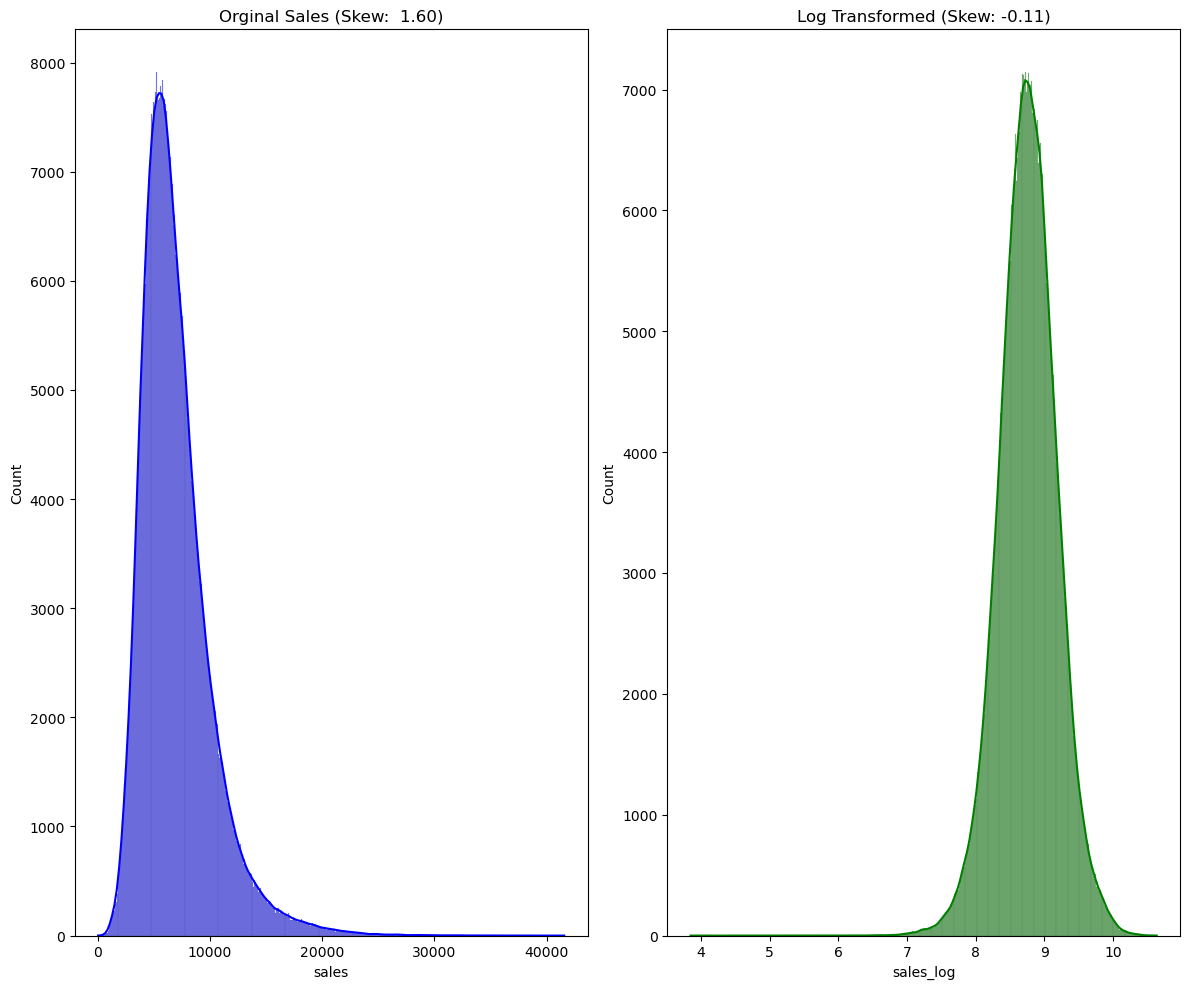

In [42]:
# Visualize the sales date
plt.figure(figsize=(12,10))

plt.subplot(1, 2, 1)
sns.histplot(sales_df_encoded['sales'], kde=True, color ='blue')
plt.title(f'Orginal Sales (Skew: {sales_df_encoded['sales'].skew(): .2f})')
sales_df_encoded

# Plot Log Transformed
plt.subplot(1, 2, 2)
sales_df_encoded['sales_log'] = np.log1p(sales_df_encoded['sales'])
sns.histplot(sales_df_encoded['sales_log'], kde=True, color='green')
plt.title(f'Log Transformed (Skew: {sales_df_encoded["sales_log"].skew():.2f})')

plt.tight_layout()
plt.show()

In [43]:
#The data set is right-skewed as most data points are squashed on the left side, lower sales.
#However there is a long tail on the left. So applying a log transformation helps stopping the model from over focusing on the higher numbers. 

In [44]:
sales_df_encoded['sales_log'] = np.log1p(sales_df_encoded['sales'])

In [45]:
# drop nb_customers_on_day
sales_df_encoded.drop('nb_customers_on_day', axis= 1)

,Unnamed: 0,store_ID,date,promotion,school_holiday,sales,state_holiday_a,state_holiday_b,state_holiday_c,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,day_of_week_7,sales_log
0,425390,366,2013-04-18,0,0,4422,0,0,0,0,0,1,0,0,0,8.394573
1,291687,394,2015-04-11,0,0,8297,0,0,0,0,0,0,0,1,0,9.023770
2,411278,807,2013-08-29,1,0,9729,0,0,0,0,0,1,0,0,0,9.182969
3,664714,802,2013-05-28,1,0,6513,0,0,0,1,0,0,0,0,0,8.781709
4,540835,726,2013-10-10,1,0,10882,0,0,0,0,0,1,0,0,0,9.294957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640833,122579,77,2015-01-17,0,0,8219,0,0,0,0,0,0,0,1,0,9.014325
640835,359783,409,2013-10-26,0,0,4553,0,0,0,0,0,0,0,1,0,8.423761
640836,152315,97,2014-04-14,1,0,12307,0,0,0,0,0,0,0,0,0,9.418005
640837,117952,987,2014-07-07,0,0,6800,0,0,0,0,0,0,0,0,0,8.824825


In [46]:
#change date to datetime

sales_df_encoded['date'] = pd.to_datetime(sales_df_encoded['date'])
sales_df_encoded['month'] = sales_df_encoded['date'].dt.month
sales_df_encoded['day'] = sales_df_encoded['date'].dt.day
sales_df_encoded = sales_df_encoded.drop(columns=['date'])

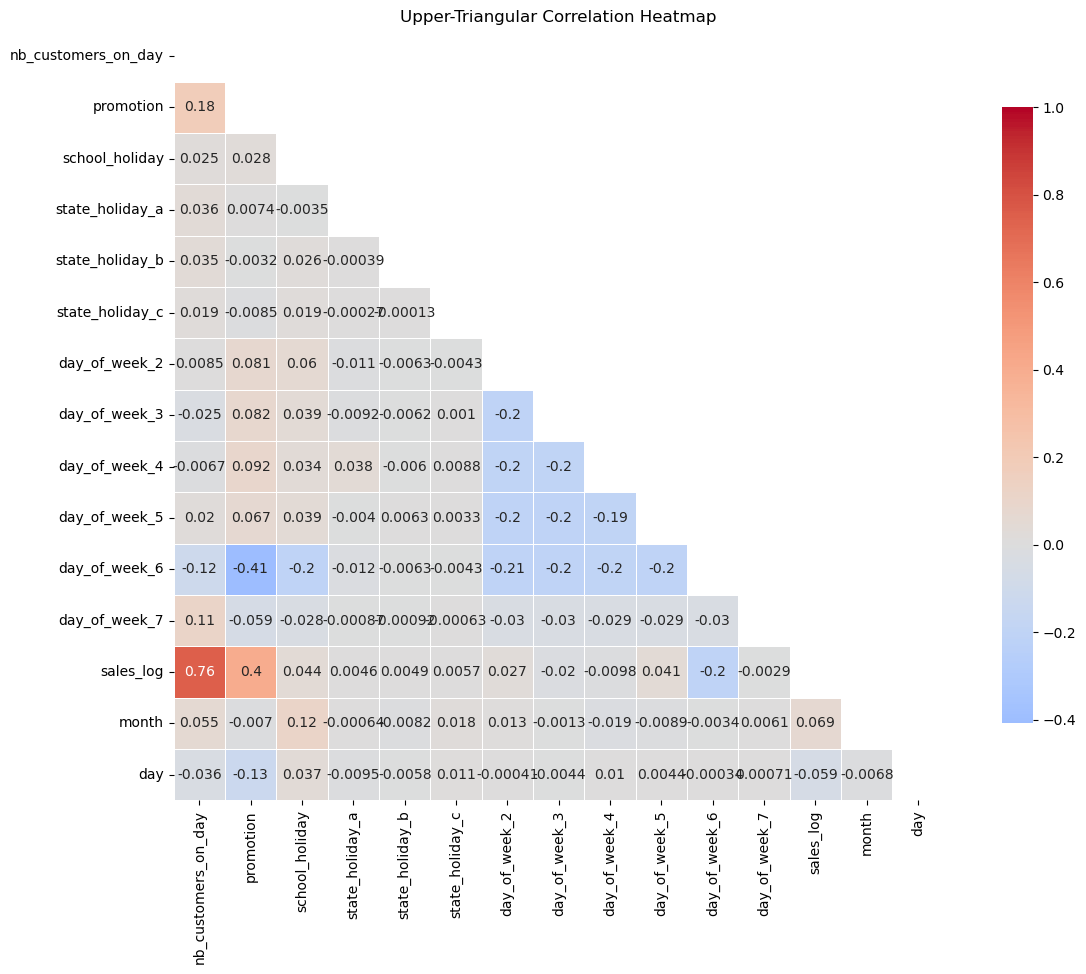

In [47]:
import seaborn as sns
useful_cols = [col for col in sales_df_encoded.columns if col not in ['Unnamed: 0', 'store_ID', 'sales', 'open']]

corr = sales_df_encoded[useful_cols].corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(15,10))

sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8}, 
            annot=True) 
plt.title('Upper-Triangular Correlation Heatmap')
plt.show()


In [48]:
###For later when transforming log back to dollar amounts. Variable names must be changed.

#log_predictions = model.predict(X_test)

#final_sales_predictions = np.expm1(log_predictions)

#test_df['sales_prediction'] = final_sales_predictions
#test_df.loc[test_df['open'] == 0, 'sales_prediction'] = 0


#submission = test_df[['Id', 'sales_prediction']]
#submission.to_csv('my_winning_submission.csv', index=False)